In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn

import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader


In [2]:
# Defining the neural network class
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.sigmoid = nn.Sigmoid()
        self.fc2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.sigmoid(x) 
        x = self.fc2(x) 
        x = self.sigmoid(x)
        return x

In [3]:
image_size = (100, 100)
train_folder = "C:/Users/HP/Documents/AYOMIDE's  BOOKS/Data files/Animal classification/train"
test_folder = "C:/Users/HP/Documents/AYOMIDE's  BOOKS/Data files/Animal classification/test"

# Create image data loaders
train_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
])

train_dataset = ImageFolder(train_folder, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = ImageFolder(test_folder, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

#Neural network parameters
input_size = image_size[0] * image_size[1] * 3  #RGB
hidden_size = 64
output_size = 1



In [4]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre
lri = []
model = NeuralNetwork(input_size, hidden_size, output_size)
lossi = []

# Define the loss function and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adadelta(model.parameters(), lr=0.001 )



# Training the neural network
epochs = 100
for epoch in range(epochs):
    for images, labels in train_loader:
        images = images.view(images.size(0), -1)  # Flatten images into a vector
        outputs = model(images)
        loss = criterion(outputs, labels.float().view(-1, 1))
        
        optimizer.zero_grad()
        loss.backward()
        lr = lrs[epoch]
        optimizer.step()
    
    print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item()}')
    lossi.append(loss.item())
    lri.append(lr)



Epoch 1/100, Loss: 0.7170724272727966
Epoch 2/100, Loss: 0.6390066146850586
Epoch 3/100, Loss: 0.7136355042457581
Epoch 4/100, Loss: 0.6984844207763672
Epoch 5/100, Loss: 0.7286264896392822
Epoch 6/100, Loss: 0.6598612666130066
Epoch 7/100, Loss: 0.6799362897872925
Epoch 8/100, Loss: 0.7026436924934387
Epoch 9/100, Loss: 0.6731995940208435
Epoch 10/100, Loss: 0.7160290479660034
Epoch 11/100, Loss: 0.711506187915802
Epoch 12/100, Loss: 0.6723904013633728
Epoch 13/100, Loss: 0.6813786029815674
Epoch 14/100, Loss: 0.69735187292099
Epoch 15/100, Loss: 0.7025676369667053
Epoch 16/100, Loss: 0.7076043486595154
Epoch 17/100, Loss: 0.7115357518196106
Epoch 18/100, Loss: 0.683617889881134
Epoch 19/100, Loss: 0.6769073009490967
Epoch 20/100, Loss: 0.7056370973587036
Epoch 21/100, Loss: 0.7105054259300232
Epoch 22/100, Loss: 0.7362998723983765
Epoch 23/100, Loss: 0.7073365449905396
Epoch 24/100, Loss: 0.7023725509643555
Epoch 25/100, Loss: 0.6824639439582825
Epoch 26/100, Loss: 0.7030529379844666

# MODEL EVALUATION

In [6]:
# Evaluate the model
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.view(images.size(0), -1)
        outputs = model(images)
        predicted = torch.round(outputs)
        total += labels.size(0)
        correct += (predicted == labels.float().view(-1, 1)).sum().item()

    accuracy = correct / total
    print(f'Accuracy: {accuracy * 100}%')

Accuracy: 52.142857142857146%


The predicted class is: dog


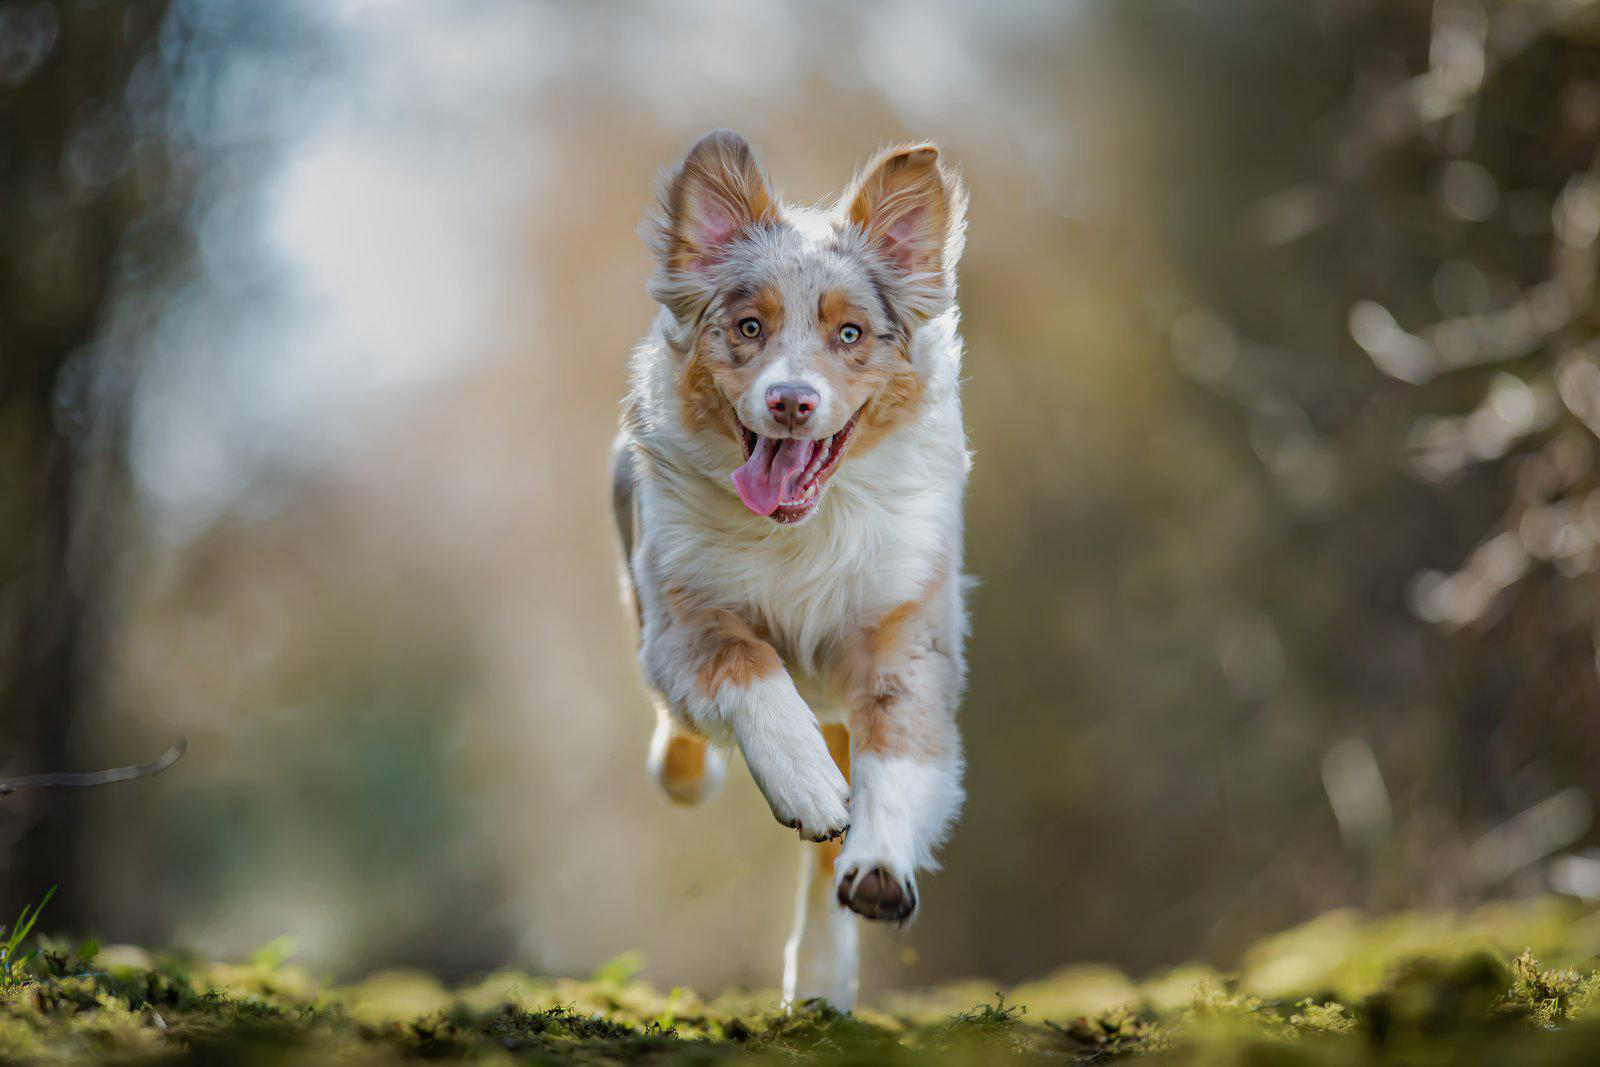

In [13]:
from PIL import Image
image_path = "C:/Users/HP/Documents/AYOMIDE's  BOOKS/Data files/Animal classification/train/dogs/dog_0.jpg"
image = Image.open(image_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
])
image_tensor = transform(image).unsqueeze(0)  # Batch dimension


# Making a prediction
model.eval()
with torch.no_grad():
    output = model(image_tensor.view(image_tensor.size(0), -1))
    prediction = torch.round(output).item()

# Interpreting the prediction
class_names = ['cat', 'dog']
predicted_class = class_names[int(prediction)]
print(f'The predicted class is: {predicted_class}')
image

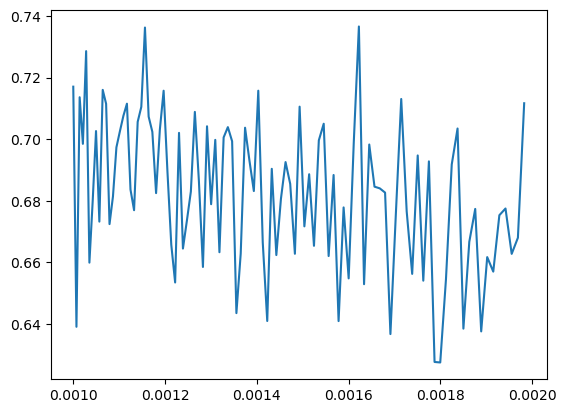

In [8]:
plt.plot(lri, lossi);

The predicted class is: cat


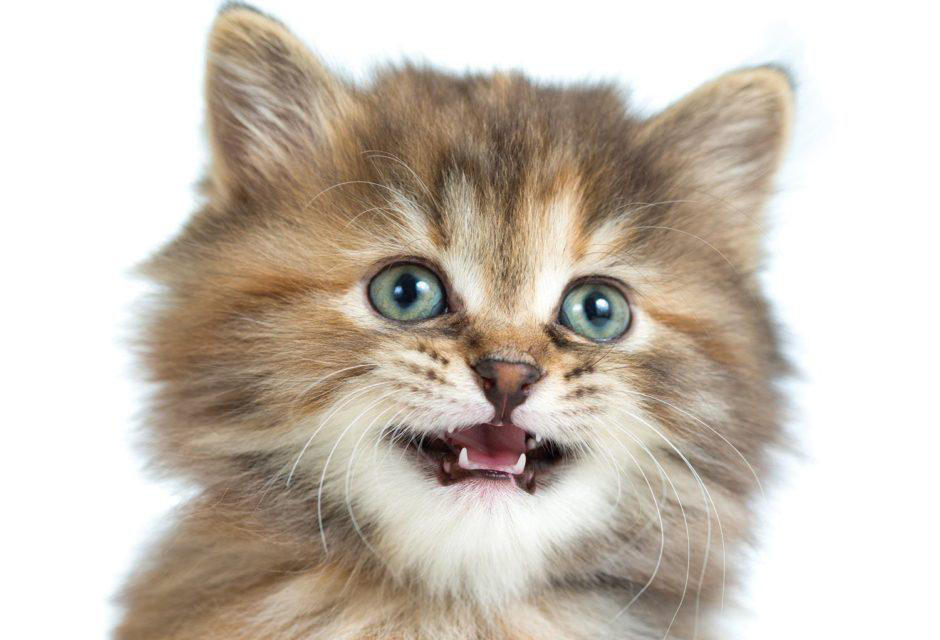

In [11]:
from PIL import Image
image_path = "C:/Users/HP/Documents/AYOMIDE's  BOOKS/Data files/Animal classification/train/cats/cat_2.jpg"
image = Image.open(image_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
])
image_tensor = transform(image).unsqueeze(0)  # Batch dimension


# Making a prediction
model.eval()
with torch.no_grad():
    output = model(image_tensor.view(image_tensor.size(0), -1))
    prediction = torch.round(output).item()

# Interpreting the prediction
class_names = ['cat', 'dog']
predicted_class = class_names[int(prediction)]
print(f'The predicted class is: {predicted_class}')
image